# Fuzzy Logic — Similar Name Matching

An intelligent matching module based on **fuzzy sets**: decide whether two person-name strings refer to the same entity despite typos, nicknames, shortenings, or spelling variants.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from itertools import combinations
from tabulate import tabulate
from rapidfuzz import fuzz
from Levenshtein import distance as levenshtein_distance
import fuzzy
import skfuzzy as fuzz_logic

### 1. Завантаження датасету

In [2]:
data = pd.read_csv("corner_cases_new.csv", encoding="latin-1")

data["Name1"] = data["Name1"].astype(str).str.strip().str.replace(r"[\xa0\u00a0]", "", regex=True)
data["Name2"] = data["Name2"].astype(str).str.strip().str.replace(r"[\xa0\u00a0]", "", regex=True)

def clean_cell(val):
    parts = str(val).split(",")
    if len(parts) == 2 and parts[0].strip() == parts[1].strip():
        return parts[0].strip()
    return val

data["Name1"] = data["Name1"].apply(clean_cell)
data = data[(data["Name1"].str.len() > 0) & (data["Name2"].str.len() > 0)].reset_index(drop=True)

data.head()

,Name1,Name2
0,Mehul Gupta,Meryl Gupta
1,John Andrew Lewis,Jahn Andrej Levis
2,Cyndi Eric Wood,Candice Erick Waud
3,Mary Ellen,Mari Ehlen
4,Carlos Alfonzo Diaz,Carlow Diez


In [3]:
data.columns

Index(['Name1', 'Name2'], dtype='object')

### 2. Реалізація метрик схожості

Для кожної пари рядків рахуємо три метрики:
- **Jaro-Winkler** — схожість символів з бонусом за спільний початок
- **Soundex** — фонетична схожість (чи однаково звучать)
- **Damerau-Levenshtein** — кількість операцій редагування

In [4]:
def jaro_winkler_score(str1, str2):
    score = fuzz.token_sort_ratio(str(str1), str(str2)) / 100
    return round(score, 3)

soundex_encoder = fuzzy.Soundex(4)

def soundex_score(str1, str2):
    try:
        s1 = soundex_encoder(str(str1).split()[0])
        s2 = soundex_encoder(str(str2).split()[0])
        return 1.0 if s1 == s2 else 0.0
    except:
        return 0.0

def dl_score(str1, str2):
    dist = levenshtein_distance(str(str1).lower(), str(str2).lower())
    return round(1 / (1 + dist), 3), dist

In [5]:
def get_dl_info(row):
    dl, raw_dist = dl_score(row["Name1"], row["Name2"])
    return pd.Series([dl, raw_dist])

data["jw"]      = data.apply(lambda x: jaro_winkler_score(x["Name1"], x["Name2"]), axis=1)
data["soundex"] = data.apply(lambda x: soundex_score(x["Name1"], x["Name2"]), axis=1)

data[["dl", "dl_n_oper"]] = data.apply(get_dl_info, axis=1)

In [6]:
data["len_name1"] = data["Name1"].str.len()
data["len_name2"] = data["Name2"].str.len()
data["len_avg"]   = ((data["len_name1"] + data["len_name2"]) / 2).round(1)
data["len_diff"]  = (data["len_name1"] - data["len_name2"]).abs()

In [7]:
data.head()

,Name1,Name2,jw,soundex,dl,dl_n_oper,len_name1,len_name2,len_avg,len_diff
0,Mehul Gupta,Meryl Gupta,0.818,0.0,0.333,2.0,11,11,11.0,0
1,John Andrew Lewis,Jahn Andrej Levis,0.824,1.0,0.250,3.0,17,17,17.0,0
2,Cyndi Eric Wood,Candice Erick Waud,0.727,0.0,0.143,6.0,15,18,16.5,3
3,Mary Ellen,Mari Ehlen,0.800,1.0,0.333,2.0,10,10,10.0,0
4,Carlos Alfonzo Diaz,Carlow Diez,0.600,0.0,0.091,10.0,19,11,15.0,8


In [8]:
metrics = {
    "Jaro-Winkler (jw)": data["jw"],
    "Soundex":           data["soundex"],
    "D-L (dl)":          data["dl"],
    "Length (len_avg)":  data["len_avg"],
}

for name, series in metrics.items():
    print(f"\n  {name}:")
    print(f"    min    = {series.min():.3f}")
    print(f"    25%    = {series.quantile(0.25):.3f}")
    print(f"    median = {series.median():.3f}")
    print(f"    75%    = {series.quantile(0.75):.3f}")
    print(f"    max    = {series.max():.3f}")
    print(f"    mean   = {series.mean():.3f}")
    print(f"    std    = {series.std():.3f}")


  Jaro-Winkler (jw):
    min    = 0.364
    25%    = 0.839
    median = 0.895
    75%    = 0.938
    max    = 1.000
    mean   = 0.858
    std    = 0.114

  Soundex:
    min    = 0.000
    25%    = 0.000
    median = 1.000
    75%    = 1.000
    max    = 1.000
    mean   = 0.661
    std    = 0.474

  D-L (dl):
    min    = 0.053
    25%    = 0.250
    median = 0.333
    75%    = 0.500
    max    = 1.000
    mean   = 0.336
    std    = 0.154

  Length (len_avg):
    min    = 3.000
    25%    = 14.500
    median = 18.000
    75%    = 20.500
    max    = 26.000
    mean   = 17.188
    std    = 4.680


### 3. Нечіткі множини та функції належності

In [9]:
x_sim = np.arange(0, 1.01, 0.01)
sim_low    = fuzz_logic.trimf(x_sim, [0.0,  0.0,   0.60])
sim_medium = fuzz_logic.trimf(x_sim, [0.50, 0.667, 0.82])
sim_high   = fuzz_logic.trimf(x_sim, [0.70, 1.0,   1.0])

x_phon = np.arange(0, 1.01, 0.01)
phon_none    = fuzz_logic.trimf(x_phon, [0.0, 0.0, 0.4])
phon_partial = fuzz_logic.trimf(x_phon, [0.3, 0.5, 0.7])
phon_full    = fuzz_logic.trimf(x_phon, [0.6, 1.0, 1.0])

x_dl = np.arange(0, 1.01, 0.01)
dl_low    = fuzz_logic.trimf(x_dl, [0.0,  0.05, 0.20])
dl_medium = fuzz_logic.trimf(x_dl, [0.10, 0.25, 0.45])
dl_high   = fuzz_logic.trimf(x_dl, [0.35, 1.0,  1.0])

x_len = np.arange(2, 40, 0.5)
len_short  = fuzz_logic.trimf(x_len, [2.0,  2.0,  14.0])
len_medium = fuzz_logic.trimf(x_len, [8.0,  16.0, 26.0])
len_long   = fuzz_logic.trimf(x_len, [20.0, 39.5, 39.5])

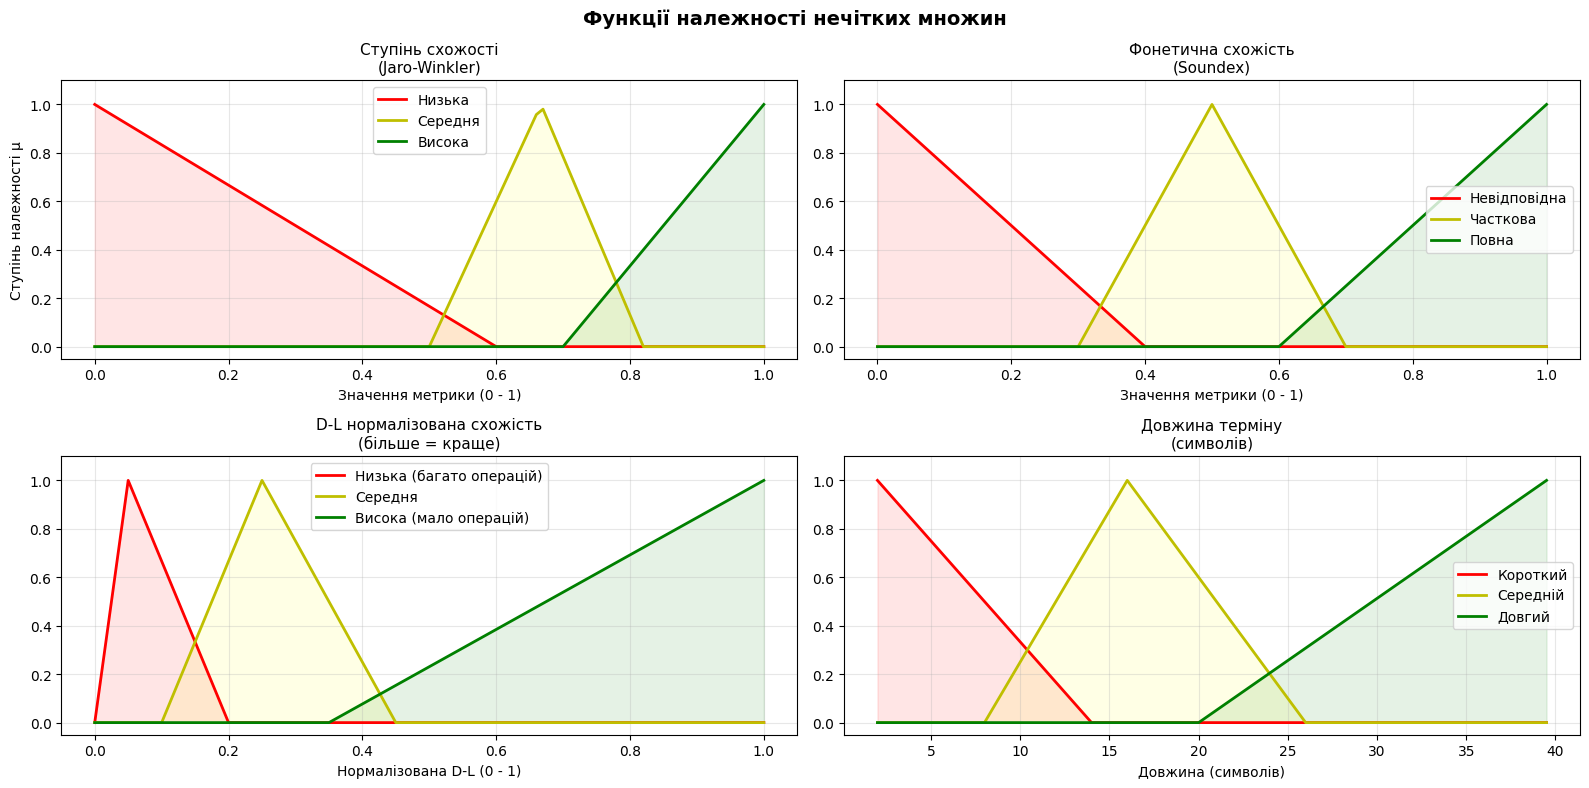

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("Функції належності нечітких множин", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(x_sim, sim_low,    "r-", linewidth=2, label="Низька")
ax.plot(x_sim, sim_medium, "y-", linewidth=2, label="Середня")
ax.plot(x_sim, sim_high,   "g-", linewidth=2, label="Висока")
ax.fill_between(x_sim, sim_low,    alpha=0.1, color="red")
ax.fill_between(x_sim, sim_medium, alpha=0.1, color="yellow")
ax.fill_between(x_sim, sim_high,   alpha=0.1, color="green")
ax.set_title("Ступінь схожості\n(Jaro-Winkler)", fontsize=11)
ax.set_xlabel("Значення метрики (0 - 1)")
ax.set_ylabel("Ступінь належності μ")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

ax = axes[0, 1]
ax.plot(x_phon, phon_none,    "r-", linewidth=2, label="Невідповідна")
ax.plot(x_phon, phon_partial, "y-", linewidth=2, label="Часткова")
ax.plot(x_phon, phon_full,    "g-", linewidth=2, label="Повна")
ax.fill_between(x_phon, phon_none,    alpha=0.1, color="red")
ax.fill_between(x_phon, phon_partial, alpha=0.1, color="yellow")
ax.fill_between(x_phon, phon_full,    alpha=0.1, color="green")
ax.set_title("Фонетична схожість\n(Soundex)", fontsize=11)
ax.set_xlabel("Значення метрики (0 - 1)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

ax = axes[1, 0]
ax.plot(x_dl, dl_low,    "r-", linewidth=2, label="Низька (багато операцій)")
ax.plot(x_dl, dl_medium, "y-", linewidth=2, label="Середня")
ax.plot(x_dl, dl_high,   "g-", linewidth=2, label="Висока (мало операцій)")
ax.fill_between(x_dl, dl_low,    alpha=0.1, color="red")
ax.fill_between(x_dl, dl_medium, alpha=0.1, color="yellow")
ax.fill_between(x_dl, dl_high,   alpha=0.1, color="green")
ax.set_title("D-L нормалізована схожість\n(більше = краще)", fontsize=11)
ax.set_xlabel("Нормалізована D-L (0 - 1)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

ax = axes[1, 1]
ax.plot(x_len, len_short,  "r-", linewidth=2, label="Короткий")
ax.plot(x_len, len_medium, "y-", linewidth=2, label="Середній")
ax.plot(x_len, len_long,   "g-", linewidth=2, label="Довгий")
ax.fill_between(x_len, len_short,  alpha=0.1, color="red")
ax.fill_between(x_len, len_medium, alpha=0.1, color="yellow")
ax.fill_between(x_len, len_long,   alpha=0.1, color="green")
ax.set_title("Довжина терміну\n(символів)", fontsize=11)
ax.set_xlabel("Довжина (символів)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### 4. Функція фазифікації

In [11]:
def fuzzify_similarity(value):
    return {
        "low":    fuzz_logic.interp_membership(x_sim, sim_low,    value),
        "medium": fuzz_logic.interp_membership(x_sim, sim_medium, value),
        "high":   fuzz_logic.interp_membership(x_sim, sim_high,   value),
    }

def fuzzify_phonetic(value):
    return {
        "none":    fuzz_logic.interp_membership(x_phon, phon_none,    value),
        "partial": fuzz_logic.interp_membership(x_phon, phon_partial, value),
        "full":    fuzz_logic.interp_membership(x_phon, phon_full,    value),
    }

def fuzzify_dl(value):
    return {
        "low":    fuzz_logic.interp_membership(x_dl, dl_low,    value),
        "medium": fuzz_logic.interp_membership(x_dl, dl_medium, value),
        "high":   fuzz_logic.interp_membership(x_dl, dl_high,   value),
    }

def fuzzify_length(value):
    return {
        "short":  fuzz_logic.interp_membership(x_len, len_short,  value),
        "medium": fuzz_logic.interp_membership(x_len, len_medium, value),
        "long":   fuzz_logic.interp_membership(x_len, len_long,   value),
    }

In [12]:
data["sim_low"]    = data["jw"].apply(lambda x: fuzzify_similarity(x)["low"])
data["sim_medium"] = data["jw"].apply(lambda x: fuzzify_similarity(x)["medium"])
data["sim_high"]   = data["jw"].apply(lambda x: fuzzify_similarity(x)["high"])

data["phon_none"]    = data["soundex"].apply(lambda x: fuzzify_phonetic(x)["none"])
data["phon_partial"] = data["soundex"].apply(lambda x: fuzzify_phonetic(x)["partial"])
data["phon_full"]    = data["soundex"].apply(lambda x: fuzzify_phonetic(x)["full"])

data["dl_low"]    = data["dl"].apply(lambda x: fuzzify_dl(x)["low"])
data["dl_medium"] = data["dl"].apply(lambda x: fuzzify_dl(x)["medium"])
data["dl_high"]   = data["dl"].apply(lambda x: fuzzify_dl(x)["high"])

data["len_short"]  = data["len_avg"].apply(lambda x: fuzzify_length(x)["short"])
data["len_medium"] = data["len_avg"].apply(lambda x: fuzzify_length(x)["medium"])
data["len_long"]   = data["len_avg"].apply(lambda x: fuzzify_length(x)["long"])

In [13]:
data.head()

,Name1,Name2,jw,soundex,dl,dl_n_oper,len_name1,len_name2,len_avg,len_diff,...,sim_high,phon_none,phon_partial,phon_full,dl_low,dl_medium,dl_high,len_short,len_medium,len_long
0,Mehul Gupta,Meryl Gupta,0.818,0.0,0.333,2.0,11,11,11.0,0,...,0.393333,1.0,0.0,0.0,0.000000,0.585000,0.0,0.250000,0.375,0.0
1,John Andrew Lewis,Jahn Andrej Levis,0.824,1.0,0.250,3.0,17,17,17.0,0,...,0.413333,0.0,0.0,1.0,0.000000,1.000000,0.0,0.000000,0.900,0.0
2,Cyndi Eric Wood,Candice Erick Waud,0.727,0.0,0.143,6.0,15,18,16.5,3,...,0.090000,1.0,0.0,0.0,0.380000,0.286667,0.0,0.000000,0.950,0.0
3,Mary Ellen,Mari Ehlen,0.800,1.0,0.333,2.0,10,10,10.0,0,...,0.333333,0.0,0.0,1.0,0.000000,0.585000,0.0,0.333333,0.250,0.0
4,Carlos Alfonzo Diaz,Carlow Diez,0.600,0.0,0.091,10.0,19,11,15.0,8,...,0.000000,1.0,0.0,0.0,0.726667,0.000000,0.0,0.000000,0.875,0.0


### 5. База правил нечіткого виведення (if-then)

In [14]:
rule1_activation = np.minimum(data["sim_high"], data["phon_full"])
rule1_output     = rule1_activation * 0.90

rule2_activation = np.minimum.reduce([data["sim_medium"], data["dl_high"], data["len_short"]])
rule2_output     = rule2_activation * 0.80

rule3_activation = np.minimum(data["sim_low"], data["phon_none"])
rule3_output     = rule3_activation * 0.80

rule4_activation = np.minimum(data["sim_high"], np.maximum(data["len_medium"], data["len_long"]))
rule4_output     = rule4_activation * 0.75

positive_signal = np.maximum.reduce([rule1_output, rule2_output, rule4_output])
penalty         = rule3_output

data["result"] = np.maximum(0.0, np.minimum(1.0, positive_signal - penalty * 0.3))

In [15]:
data.head()

,Name1,Name2,jw,soundex,dl,dl_n_oper,len_name1,len_name2,len_avg,len_diff,...,phon_none,phon_partial,phon_full,dl_low,dl_medium,dl_high,len_short,len_medium,len_long,result
0,Mehul Gupta,Meryl Gupta,0.818,0.0,0.333,2.0,11,11,11.0,0,...,1.0,0.0,0.0,0.000000,0.585000,0.0,0.250000,0.375,0.0,0.28125
1,John Andrew Lewis,Jahn Andrej Levis,0.824,1.0,0.250,3.0,17,17,17.0,0,...,0.0,0.0,1.0,0.000000,1.000000,0.0,0.000000,0.900,0.0,0.37200
2,Cyndi Eric Wood,Candice Erick Waud,0.727,0.0,0.143,6.0,15,18,16.5,3,...,1.0,0.0,0.0,0.380000,0.286667,0.0,0.000000,0.950,0.0,0.06750
3,Mary Ellen,Mari Ehlen,0.800,1.0,0.333,2.0,10,10,10.0,0,...,0.0,0.0,1.0,0.000000,0.585000,0.0,0.333333,0.250,0.0,0.30000
4,Carlos Alfonzo Diaz,Carlow Diez,0.600,0.0,0.091,10.0,19,11,15.0,8,...,1.0,0.0,0.0,0.726667,0.000000,0.0,0.000000,0.875,0.0,0.00000


### 6. Результати

In [16]:
data.sort_values(by="result", ascending=False).head(10)[["Name1", "Name2", "result"]]

,Name1,Name2,result
424,Leena,Leena,0.900
437,Uma,Uma,0.900
436,Tara,Tara,0.900
425,Lily,Lily,0.900
426,Maya,Maya,0.900
428,Milan,Milan,0.900
422,Kirin,Kirin,0.900
429,Mira,Mira,0.900
104,Isabella Christian Clark,Isabella Christian Cleark,0.840
145,Danna Kingston Martinez,Dianna Kingston Martinez,0.837


In [17]:
for threshold in [0.4, 0.5, 0.6, 0.7]:
    count = (data["result"] >= threshold).sum()
    print(f"Поріг {threshold}: {count} пар належать ({count/len(data)*100:.1f}%)")

Поріг 0.4: 281 пар належать (64.0%)
Поріг 0.5: 219 пар належать (49.9%)
Поріг 0.6: 157 пар належать (35.8%)
Поріг 0.7: 85 пар належать (19.4%)


In [18]:
THRESHOLD = 0.5

data["probability"] = (data["result"] * 100).round(1)
data["decision"]    = data["result"].apply(
    lambda x: "Належить" if x >= THRESHOLD else "Не належить"
)

belongs = data[data["result"] >= THRESHOLD].sort_values("result", ascending=False)
print(belongs[["Name1", "Name2", "decision"]].to_string(index=False))

                     Name1                      Name2 decision
                       Uma                        Uma Належить
                      Mira                       Mira Належить
                     Kirin                      Kirin Належить
                     Leena                      Leena Належить
                      Maya                       Maya Належить
                     Milan                      Milan Належить
                      Lily                       Lily Належить
                      Tara                       Tara Належить
  Isabella Christian Clark  Isabella Christian Cleark Належить
   Danna Kingston Martinez   Dianna Kingston Martinez Належить
    Saanchi Aniruddh Soman    Saanchi Aniruddh Solman Належить
     Amelia Brayden Walker     Ameliya Brayden Walker Належить
      John Adrian Peterson      John Adriano Peterson Належить
     Carolina Johnny Gomez       Carlina Johnny Gomez Належить
       Aaradhya Aditya Lal       Aaradhya Aditya Lalk Н

In [19]:
top15 = data.sort_values("result", ascending=False).head(15).copy()
top15["probability"] = (top15["result"] * 100).round(1)
top15["decision"]    = top15["result"].apply(
    lambda x: "Належить" if x >= THRESHOLD else "Не належить"
)
top15 = top15.reset_index(drop=True)

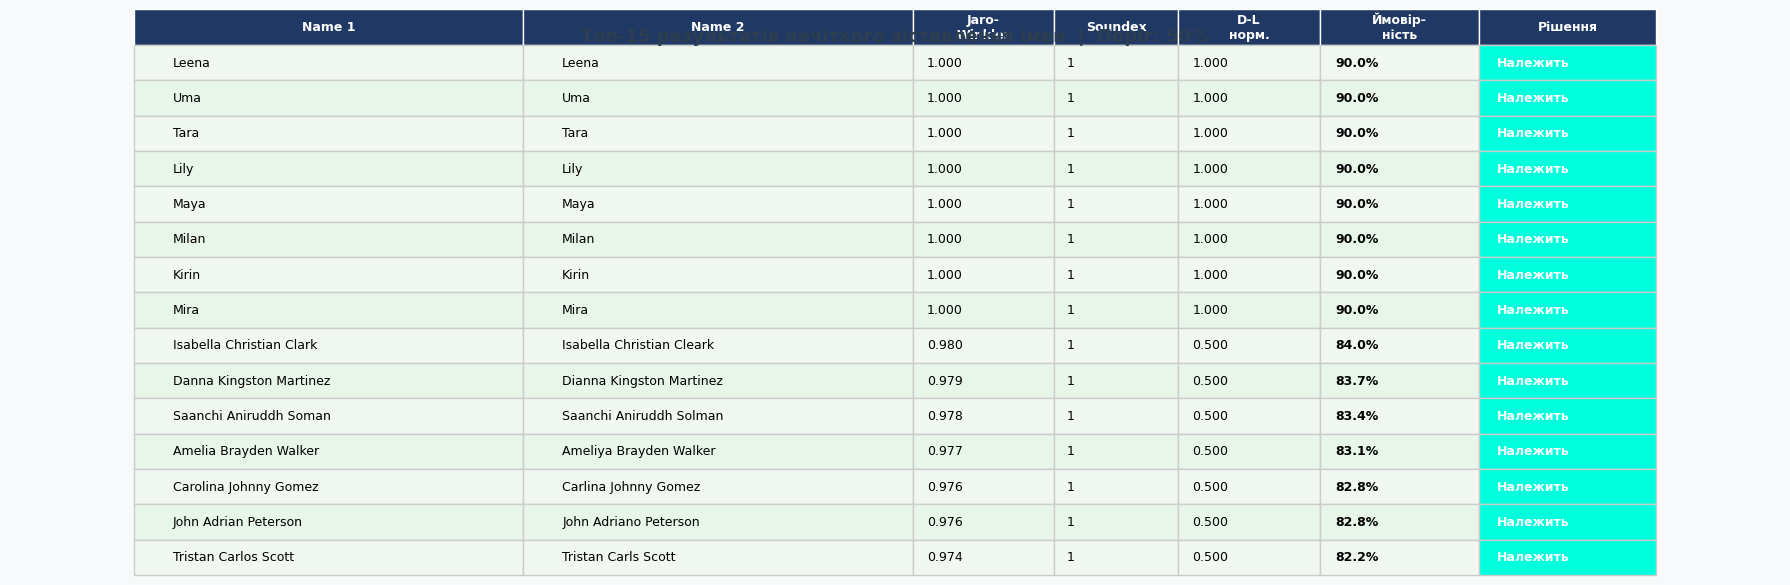

In [20]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.axis("off")
fig.patch.set_facecolor("#F8F9FA")

cell_data = []
for _, row in top15.iterrows():
    cell_data.append([
        row["Name1"][:32],
        row["Name2"][:32],
        f"{row['jw']:.3f}",
        f"{int(row['soundex'])}",
        f"{row['dl']:.3f}",
        f"{row['probability']}%",
        row["decision"]
    ])

col_labels = ["Name 1", "Name 2", "Jaro-\nWinkler", "Soundex", "D-L\nнорм.", "Ймовір-\nність", "Рішення"]
col_widths = [0.22, 0.22, 0.08, 0.07, 0.08, 0.09, 0.10]

table = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    cellLoc="left",
    loc="center",
    colWidths=col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor("#1F3864")
    cell.set_text_props(color="white", fontweight="bold", fontsize=9)
    cell.set_edgecolor("white")

for i in range(1, len(cell_data) + 1):
    row_data = cell_data[i - 1]
    is_belongs = row_data[6] == "Належить"
    for j in range(len(col_labels)):
        cell = table[i, j]
        cell.set_edgecolor("#CCCCCC")
        if is_belongs:
            bg = "#E8F5E9" if i % 2 == 0 else "#F1F8F1"
        else:
            bg = "#FFF3E0" if i % 2 == 0 else "#FFF8F0"
        cell.set_facecolor(bg)
        if j == 6:
            if is_belongs:
                cell.set_facecolor("#00FFDD")
                cell.set_text_props(color="white", fontweight="bold")
            else:
                cell.set_facecolor("#E74C3C")
                cell.set_text_props(color="white", fontweight="bold")
        if j == 5:
            cell.set_text_props(fontweight="bold")

ax.set_title(
    f"Топ-15 результатів нечіткого зіставлення імен  |  Поріг: {THRESHOLD*100:.0f}%",
    fontsize=13, fontweight="bold", pad=20, color="#2C3E50"
)

plt.tight_layout()
plt.show()

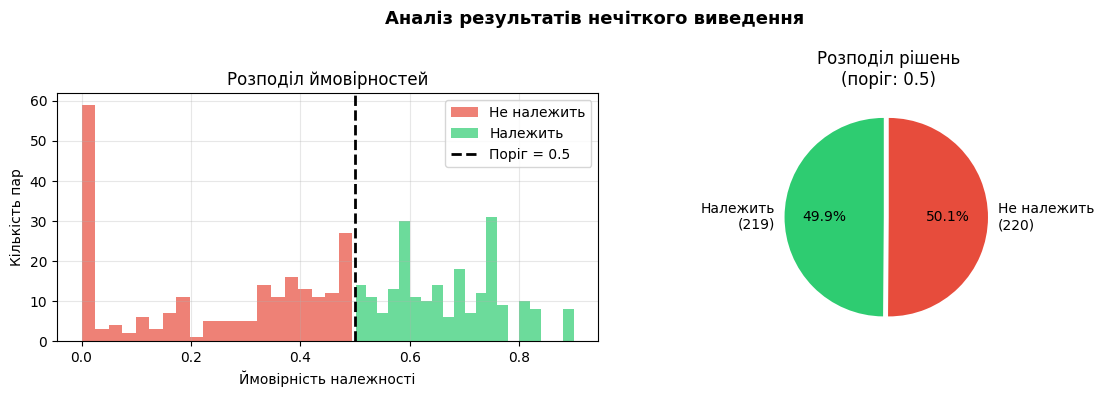

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Аналіз результатів нечіткого виведення", fontsize=13, fontweight="bold")

ax = axes[0]
belongs_data     = data[data["result"] >= THRESHOLD]["result"]
not_belongs_data = data[data["result"] <  THRESHOLD]["result"]

ax.hist(not_belongs_data, bins=20, color="#E74C3C", alpha=0.7, label="Не належить")
ax.hist(belongs_data,     bins=20, color="#2ECC71", alpha=0.7, label="Належить")
ax.axvline(x=THRESHOLD, color="black", linestyle="--", linewidth=2,
           label=f"Поріг = {THRESHOLD}")
ax.set_xlabel("Ймовірність належності")
ax.set_ylabel("Кількість пар")
ax.set_title("Розподіл ймовірностей")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
belongs_count     = len(data[data["result"] >= THRESHOLD])
not_belongs_count = len(data[data["result"] <  THRESHOLD])

ax.pie(
    [belongs_count, not_belongs_count],
    labels=[f"Належить\n({belongs_count})", f"Не належить\n({not_belongs_count})"],
    colors=["#2ECC71", "#E74C3C"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.05, 0)
)
ax.set_title(f"Розподіл рішень\n(поріг: {THRESHOLD})")

plt.tight_layout()
plt.show()

In [22]:
JW_THRESHOLD = 0.8

comparison_df = data.copy()
comparison_df["jw_decision"]    = comparison_df["jw"].apply(lambda x: "Належить" if x >= JW_THRESHOLD else "Не належить")
comparison_df["fuzzy_decision"] = comparison_df["decision"]

summary = (
    comparison_df
    .groupby(["jw_decision", "fuzzy_decision"])
    .size()
    .reset_index(name="count")
)

print("Порівняння рішень (простий поріг по JW vs нечітка модель):\n")
print(tabulate(summary, headers="keys", tablefmt="github", showindex=False))

examples = comparison_df[
    (comparison_df["jw_decision"]    == "Не належить") &
    (comparison_df["fuzzy_decision"] == "Належить")
]

if not examples.empty:
    print("\nПриклади, де Jaro-Winkler < порогу, але нечітка модель каже 'Належить':\n")
    print(
        examples[["Name1", "Name2", "jw", "result", "probability", "decision"]]
        .sort_values("result", ascending=False)
        .head(10)
        .to_string(index=False)
    )
else:
    print("\nНемає прикладів, де моделі суттєво розходяться при обраному порозі JW.")

Порівняння рішень (простий поріг по JW vs нечітка модель):

| jw_decision   | fuzzy_decision   |   count |
|---------------|------------------|---------|
| Належить      | Належить         |     219 |
| Належить      | Не належить      |     137 |
| Не належить   | Не належить      |      83 |

Немає прикладів, де моделі суттєво розходяться при обраному порозі JW.


---
## Висновки

З отриманих результатів видно, що метрика Jaro-Winkler виявилась найбільш інформативною — вона добре відловлювала пари з незначними орфографічними відмінностями та перестановками слів. Soundex показав себе як корисне доповнення саме для коротких імен, де перше слово звучить схоже, однак для довгих повних імен він часто давав збіг там, де його не було, бо враховує лише перший токен. Нормована відстань Damerau-Levenshtein добре працювала на парах з невеликою кількістю операцій редагування, але на довгих іменах її нормоване значення було стабільно низьким навіть при схожих парах, що трохи занижувало загальний результат.
Нечітка система з порогом 0.5 дозволила відфільтрувати пари, які є схожими за декількома ознаками одночасно, а не лише за однією. Порівняння з простим порогом по Jaro-Winkler показало, що нечітка модель у деяких випадках відносить пару до «належить» навіть коли JW самостійно не дотягує до порогу — завдяки тому, що в цей момент Soundex або DL компенсують недостатню схожість.